# Run 2 vs Run 3 — Domain Classifier (Two-Sample Test)

A separate, lightweight XGBoost model whose only job is to tell **Run 2**
signal events apart from **Run 3** signal events (signal_ggF + signal_VBF).
This is independent from the signal-vs-background classifiers trained in
`First_Training.ipynb` — nothing there is touched or reused as a model.

**Features:** the same 20 Optuna-tuned, decorrelated features used by the
Run-2 signal-vs-background BDT (`optuna_features_run2.json`) — not the full
set of common branches.

**Label convention:** Run 2 = 0, Run 3 = 1.

**How to read the resulting AUC:**
- AUC ≈ 0.5 → the classifier can't tell the runs apart → the feature
  distributions are effectively the same between Run 2 and Run 3.
- AUC well above 0.5 → there is a genuine distribution shift between the
  runs, and `AUC − 0.5` is roughly the effect size of that shift.

In [3]:
import uproot, pandas as pd, numpy as np
from pathlib import Path
import json
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ---- Configuration ----------------------------------------------------------
# Only the SIGNAL processes (ggF + VBF) - this compares Run 2 vs Run 3, it is
# NOT a signal-vs-background classifier. Same tree name / preselection as
# First_Training.ipynb, so the comparison reflects the phase space that
# actually enters the analysis.

BASE_DIR_R2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_R3 = Path("PPSSP_2026/1l2tau/run3")
TREE_NAME    = "AnalysisMiniTree"
PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

SIGNAL_FILES = {
    "signal_ggF": "signal_ggF.root",
    "signal_VBF": "signal_VBF.root",
}

WEIGHT_BRANCH = "weights"  # raw per-event branch, used AS-IS as sample_weight
                            # (NOT weight * weights, unlike w_phys elsewhere)

# ---- Feature list: reuse the exact 20 features from First_Training.ipynb ---
# This is the Run-2 Optuna-tuned, decorrelated feature set (OPTUNA_FEATURES),
# persisted there as optuna_features_run2.json. Using the SAME 20 features the
# signal-vs-background BDT was trained on tells us whether the variables that
# actually feed the analysis differ between Run 2 and Run 3.
FEATURES_PATH = BASE_DIR_R2 / "optuna_features_run2.json"
with open(FEATURES_PATH) as f:
    domain_features = json.load(f)

print(f"Loaded {len(domain_features)} features from {FEATURES_PATH}:")
print(domain_features)

# Sanity check: confirm every one of these branches exists in ALL FOUR signal
# files (ggF + VBF, Run2 + Run3) before we try to read them.
common = None
for base_dir in (BASE_DIR_R2, BASE_DIR_R3):
    for fname in SIGNAL_FILES.values():
        keys = set(uproot.open({str(base_dir / fname): TREE_NAME}).keys())
        common = keys if common is None else common & keys

missing = [f for f in domain_features if f not in common]
if missing:
    raise ValueError(f"Features missing from one or more signal files: {missing}")

Loaded 20 features from PPSSP_2026/1l2tau/run2/optuna_features_run2.json:
['HT_tau', 'dR_t1t2', 'm_t1t2', 'met_sumet', 'dR_l1j1', 'm_l1j', 'tau2_pt', 'met_met', 'm_ttl', 'm_l1j1', 'm_l1t', 'dR_t1t2_l1', 'tau1_eta', 'dR_l1j2', 'dR_l1t', 'tau2_eta', 'l1_eta', 'dR_l1t2', 'l1_e', 'm_t2j1']


In [4]:
# ---- Extraction loop ---------------------------------------------------------
# Label: Run 2 = 0, Run 3 = 1 (the target of THIS classifier only).

frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_R2), (1, "Run 3", BASE_DIR_R3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        df["process"]   = proc
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(domain_data)} events "
      f"(Run 2 = {(domain_data.run_label == 0).sum()}, Run 3 = {(domain_data.run_label == 1).sum()})")

Run 2 signal_ggF  :    67075 events after preselection
Run 2 signal_VBF  :    21639 events after preselection
Run 3 signal_ggF  :   191580 events after preselection
Run 3 signal_VBF  :    13470 events after preselection

Total: 293764 events (Run 2 = 88714, Run 3 = 205050)


In [5]:
# ---- Post-concat cleaning ----------------------------------------------------
# 1) Constant / empty features -> drop (zero variance carries no separation power)

nun = domain_data[domain_features].nunique()
const = nun[nun <= 1].index.tolist()
domain_features = [f for f in domain_features if f not in const]
domain_data = domain_data.drop(columns=const)
print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

# 2) Sentinel values (e.g. -999) -> NaN; XGBoost routes NaNs natively.
for f in domain_features:
    m = domain_data[f] < -100
    if m.any():
        print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
        domain_data[f] = domain_data[f].mask(m)

print(f"\n{len(domain_features)} final features")

Dropped 0 constant/empty features:
  []

20 final features


In [6]:
# ---- Sanity checks: weight sums & negative-weight fractions ------------------
# Comparable total weight -> comparable effective normalization between runs.
# Negative weights are reported here but events are NOT dropped for that reason
# (Sherpa NLO interference effects are physical, not a data quality issue).

for run_label, run_name in [(0, "Run 2"), (1, "Run 3")]:
    subset = domain_data.loc[domain_data.run_label == run_label, WEIGHT_BRANCH]
    total_w  = subset.sum()
    neg_frac = (subset < 0).mean()
    print(f"{run_name}: sum({WEIGHT_BRANCH}) = {total_w:12.4f} | "
          f"negative-weight fraction = {neg_frac:6.2%} | n_events = {len(subset)}")

Run 2: sum(weights) =    1848.0950 | negative-weight fraction =  4.58% | n_events = 88714
Run 3: sum(weights) =    5227.1216 | negative-weight fraction =  5.80% | n_events = 205050


In [7]:
# ---- Build training arrays ----------------------------------------------------
X = domain_data[domain_features]
y = domain_data["run_label"].to_numpy()
w_raw = domain_data[WEIGHT_BRANCH].to_numpy()   # raw branch, AS-IS

# Negative sample weights corrupt XGBoost's gradient computation (same issue
# noted for w_phys in First_Training.ipynb), so training and AUC both use
# |weights|. Events are KEPT either way - only the sign is dropped, and the
# fraction of affected events was already reported above.

w_abs = np.abs(w_raw)

# --- Class balance --------------------------------------------------------
# Run 2 and Run 3 have different total weight (see sanity check above);
# without correcting for it, the run with the larger total weight would
# dominate the loss and the AUC would partly reflect a normalization
# difference rather than a genuine shape difference. We rescale per-event
# weights so both runs contribute equal total weight, rather than using
# scale_pos_weight, because we already need a custom per-event array to
# honor the "raw weights branch" requirement - stacking scale_pos_weight on
# top would double-apply the correction.

w_fit = w_abs.copy()
sum_r2, sum_r3 = w_fit[y == 0].sum(), w_fit[y == 1].sum()
w_fit[y == 1] *= sum_r2 / sum_r3
w_fit *= len(w_fit) / w_fit.sum()   # normalize mean weight to 1

print(f"Run2/Run3 total-weight ratio before balancing: {sum_r2 / sum_r3:.3f}")
print(f"Run2/Run3 total-weight ratio after balancing:  {w_fit[y == 0].sum() / w_fit[y == 1].sum():.3f}")

Run2/Run3 total-weight ratio before balancing: 0.351
Run2/Run3 total-weight ratio after balancing:  1.000


In [8]:
# ---- Stratified K-Fold cross-validation --------------------------------------
# AUC is computed ONLY on each held-out fold, never on the data its model was
# trained on. Mean ± std across folds gives both the effect size (how
# distinguishable Run2/Run3 are) and its fold-to-fold uncertainty.

N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_aucs = []
for fold, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    fold_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,            # shallow: lightweight domain check, not the main BDT
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="auc",
        early_stopping_rounds=20,
        n_jobs=-1,
        random_state=42,
    )
    fold_model.fit(
        X.iloc[idx_tr], y[idx_tr],
        sample_weight=w_fit[idx_tr],
        eval_set=[(X.iloc[idx_te], y[idx_te])],
        sample_weight_eval_set=[w_fit[idx_te]],
        verbose=False,
    )

    pred = fold_model.predict_proba(X.iloc[idx_te])[:, 1]
    fold_auc = roc_auc_score(y[idx_te], pred, sample_weight=w_abs[idx_te])
    fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS}: weighted AUC = {fold_auc:.4f}")

fold_aucs = np.array(fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS} folds: {fold_aucs.mean():.4f} \u00b1 {fold_aucs.std():.4f}")
print("(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)")

Fold 1/5: weighted AUC = 0.5366
Fold 2/5: weighted AUC = 0.5490
Fold 3/5: weighted AUC = 0.5479
Fold 4/5: weighted AUC = 0.5462
Fold 5/5: weighted AUC = 0.5425

Mean weighted AUC across 5 folds: 0.5444 ± 0.0045
(AUC ~ 0.5 -> runs indistinguishable | AUC - 0.5 ~ effect size of the Run2/Run3 shift)


Held-out AUC of this single interpretation model: 0.5366 (compare to the 5-fold mean above)

Top 20 features separating Run 2 / Run 3 (by total gain):
             total_gain  gain_frac  weight
HT_tau      5914.388184   0.159244   226.0
l1_e        5551.554199   0.149474   147.0
met_sumet   4674.107910   0.125849   160.0
tau2_pt     3144.075195   0.084654   142.0
l1_eta      2039.231812   0.054906   114.0
m_t2j1      1582.850098   0.042618    91.0
m_ttl       1358.778931   0.036585    75.0
tau1_eta    1313.023560   0.035353    86.0
dR_t1t2     1290.738037   0.034753    88.0
dR_l1j2     1281.946533   0.034516    81.0
m_l1j       1141.897339   0.030745    75.0
m_t1t2      1097.542603   0.029551    62.0
dR_l1j1     1013.417175   0.027286    69.0
met_met      937.302429   0.025237    62.0
m_l1t        917.848694   0.024713    49.0
tau2_eta     861.946411   0.023208    59.0
dR_l1t2      811.708008   0.021855    56.0
dR_t1t2_l1   798.051514   0.021487    50.0
m_l1j1       736.421692   0.0198

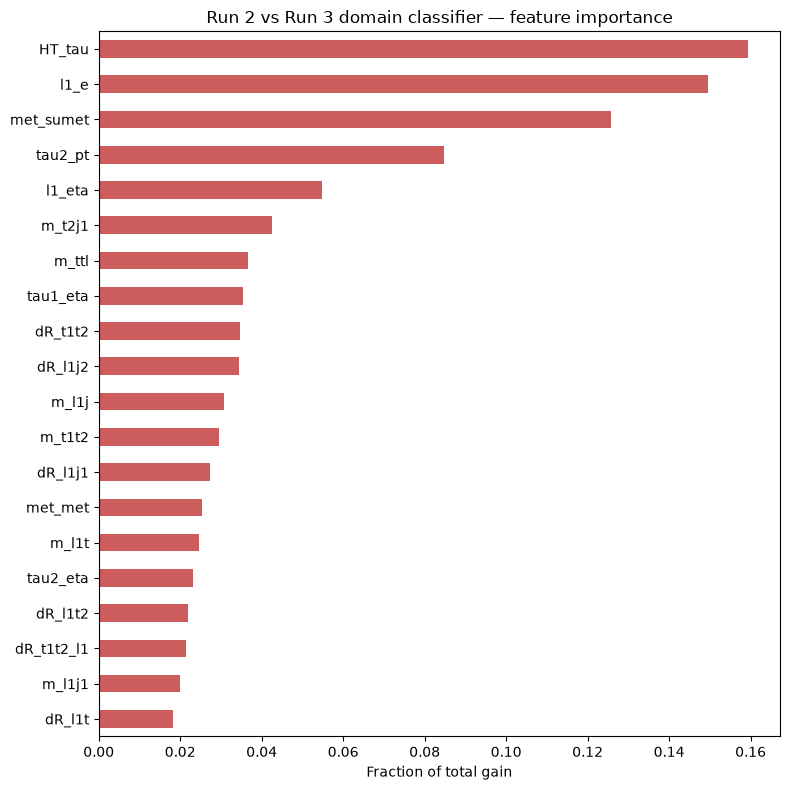

In [9]:
# ---- Final model (single split) + feature importance -------------------------
# The k-fold result above is the AUC estimate to quote. This single model is
# only to get one clean feature-importance / SHAP picture - averaging across
# 5 separate fold-models would be messier to interpret.

train_idx, test_idx = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X, y))

final_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=20,
    n_jobs=-1,
    random_state=42,
)

final_model.fit(
    X.iloc[train_idx], y[train_idx],
    sample_weight=w_fit[train_idx],
    eval_set=[(X.iloc[test_idx], y[test_idx])],
    sample_weight_eval_set=[w_fit[test_idx]],
    verbose=False,
)

pred_test = final_model.predict_proba(X.iloc[test_idx])[:, 1]
auc_test = roc_auc_score(y[test_idx], pred_test, sample_weight=w_abs[test_idx])
print(f"Held-out AUC of this single interpretation model: {auc_test:.4f} "
      f"(compare to the {N_FOLDS}-fold mean above)")

# --- Feature importance: which variables drive the Run2/Run3 difference -----
booster = final_model.get_booster()
imp = pd.DataFrame({
    t: booster.get_score(importance_type=t)
    for t in ["total_gain", "gain", "weight"]
}).reindex(domain_features).fillna(0.0)

imp = imp.sort_values("total_gain", ascending=False)
imp["gain_frac"] = imp["total_gain"] / imp["total_gain"].sum()

TOP_N = 20

print(f"\nTop {TOP_N} features separating Run 2 / Run 3 (by total gain):")
print(imp[["total_gain", "gain_frac", "weight"]].head(TOP_N).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
imp["gain_frac"].head(TOP_N)[::-1].plot.barh(ax=ax, color="indianred")
ax.set_xlabel("Fraction of total gain")
ax.set_title("Run 2 vs Run 3 domain classifier — feature importance")
plt.tight_layout()
plt.show()

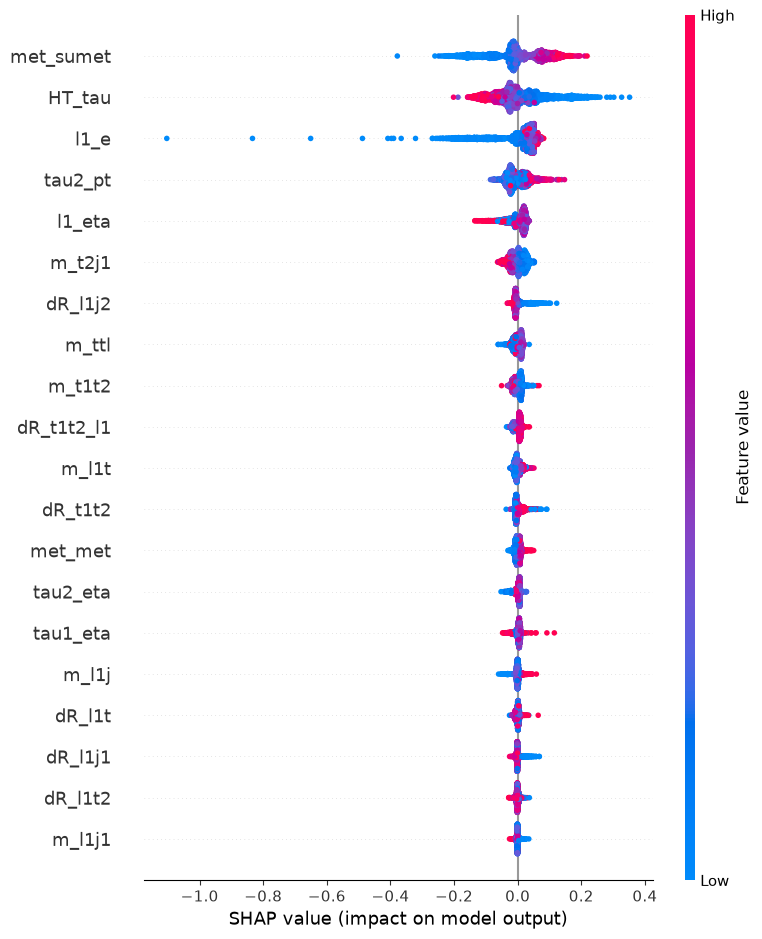

In [10]:
# ---- SHAP values (optional - only if the `shap` package is available) -------

import shap

# Subsample for speed; TreeExplainer is exact for tree models, so a
# moderate sample is enough to see the global pattern.
    
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)
X_shap = X.iloc[sample_idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, max_display=20, show=True)

